# 03 - Entrenamiento: baselines, modelos y decisiones

Objetivo: mostrar que familias de modelos se compararon, cuales ganaron, cuales se descartan y que componentes pasan al pipeline final.

Este notebook no intenta reentrenar todo desde cero. Usa dos fuentes de verdad de la carpeta:

- `training_results.csv`: corridas frescas e historicas con `valid_lwlrap`.
- `decision_matrix.csv`: decision final de cada idea (`keep`, `blend-only`, `discard`, `reference`).


## Imports y configuracion


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    from IPython.display import display
except ModuleNotFoundError:
    display = print

ROOT = Path.cwd()
if ROOT.name == '03_entrenamiento':
    ROOT = ROOT.parent
RESULTS_DIR = ROOT / '03_entrenamiento' / 'results'
FIG_DIR = RESULTS_DIR / 'figures'
INVESTIGATION = ROOT / 'investigation'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(INVESTIGATION))

pd.set_option('display.max_columns', 160)
pd.set_option('display.width', 220)
plt.style.use('default')
plt.rcParams.update({
    'figure.figsize': (9, 4.8),
    'axes.grid': True,
    'grid.alpha': 0.25,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

decision_matrix = pd.read_csv(ROOT / '03_entrenamiento' / 'decision_matrix.csv')
training_results = pd.read_csv(ROOT / '03_entrenamiento' / 'training_results.csv')
submission_candidates = pd.read_csv(ROOT / '04_final' / 'submission_candidates.csv')

training_results['valid_lwlrap_num'] = pd.to_numeric(training_results['valid_lwlrap'], errors='coerce')
print(f'training rows: {len(training_results)}')
print(f'decision rows: {len(decision_matrix)}')


training rows: 13
decision rows: 18


## 1. Que modelos se comparan

La comparacion no es una sola red contra otra. El proyecto fue sumando familias con roles distintos. En esta seccion conviene leer cada item como una familia de modelos o decisiones, no como un modelo unico.

- **Modelos tabulares sobre stats log-mel**: cada audio se resume en una fila de features numericas calculadas desde el espectrograma log-mel, por ejemplo medias, desvios, maximos y otras estadisticas por banda. Sobre esa tabla se entrena un clasificador clasico, en este proyecto `LogisticRegression` con estrategia One-vs-Rest. Es barato, reproducible y sirve como baseline fuerte, pero pierde la estructura temporal del audio.
- **CNNs sobre imagenes log-mel**: el audio se representa como una imagen tiempo-frecuencia, con bandas mel en un eje y frames temporales en el otro. Una CNN puede aprender patrones locales del espectrograma, como ataques, armonicos, ruido o texturas. Es mas expresiva que el baseline tabular, pero requiere caches grandes y entrenamiento neural.
- **Mejoras de entrenamiento neural**: no siempre cambian la familia del modelo; mejoran como se entrena la red. Aca entran inicializacion He, BatchNorm, dropout, scheduler por plateau, AdamW, early stopping y una cabeza densa de 256 unidades. La idea es presentarlas como un paquete de entrenamiento defendible, no como un numero magico.
- **Arquitecturas separables/residuales**: son CNNs con bloques mas elaborados. Las convoluciones separables reducen costo y parametros, mientras que las conexiones residuales facilitan entrenar redes mas profundas. En el repo aparecen como `separable_residual` y variantes, y funcionan como una rama arquitectonica mas fuerte que la CNN base.
- **Ramas temporales**: intentan modelar explicitamente el orden temporal del espectrograma. En vez de comprimir todo el tiempo con pooling, usan una cabeza recurrente como `BiGRU`. La version simple `temporal_bigru` aprende pero no mejora el blend; la version `separable_temporal_bigru` queda como rama util para ensemble.
- **Ensembles y post-procesado**: combinan predicciones de modelos distintos, por ejemplo CNN, sklearn y ramas temporales. La justificacion es que cada familia comete errores diferentes. El post-procesado, como `row_z` o `row_rank`, ajusta las predicciones despues del modelo; puede mejorar validacion local, pero tiene mas riesgo de sobreajustar y por eso se exige score de Kaggle antes de promoverlo.

Lo importante es separar modelo principal de ramas que solo entran por diversidad. Un componente puede ser debil individualmente y aun asi ser util si mejora el ensemble con evidencia.


,model_family,source,decision,runs
0,cnn_logmel,fresh_run,keep,2
1,cnn_logmel,fresh_run,reference,1
2,cnn_logmel,historical_investigation,keep,2
3,cnn_logmel,historical_investigation,reference,1
4,cnn_temporal,fresh_run_full_train,candidate,1
5,cnn_temporal,historical_investigation,blend-only,1
6,cnn_temporal,historical_investigation,discard,1
7,ensemble,fresh_candidate_blend,candidate_needs_kaggle_notebook,1
8,sklearn_logmel_stats,fresh_run,discard,2
9,sklearn_logmel_stats,fresh_run,keep,1


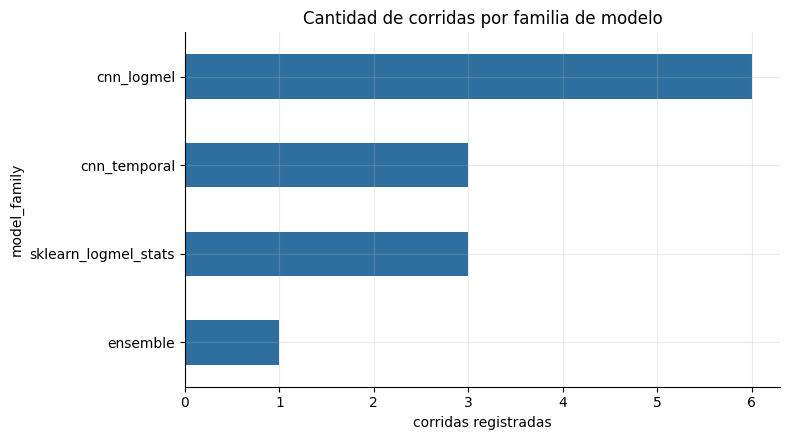

In [2]:
family_summary = (
    training_results
    .groupby(['model_family', 'source', 'decision'], dropna=False)
    .size()
    .rename('runs')
    .reset_index()
    .sort_values(['model_family', 'source', 'decision'])
)
display(family_summary)
family_summary.to_csv(RESULTS_DIR / 'model_family_summary.csv', index=False)

fig, ax = plt.subplots(figsize=(8, 4.5))
training_results['model_family'].value_counts().sort_values().plot(kind='barh', ax=ax, color='#2f6f9f')
ax.set_title('Cantidad de corridas por familia de modelo')
ax.set_xlabel('corridas registradas')
fig.tight_layout()
fig.savefig(FIG_DIR / '01_model_family_counts.png', dpi=140, bbox_inches='tight')
plt.show()


## 2. Corridas frescas

Estas son las corridas que se dejaron registradas para esta entrega. Sirven para mostrar que el flujo corre y que la direccion tecnica se sostiene: baseline tabular, CNN base, CNN mejorada y separable-residual.


,run,model_family,config,valid_lwlrap,decision,notes
5,cnn_sepres_head256_e24,cnn_logmel,Separable residual CNN + dense head256 + ReLU,0.738289,keep,Fresh run confirms final architecture direction
4,cnn_head256_he_plateau_e24,cnn_logmel,Standard CNN + He init + ReduceLROnPlateau + d...,0.673265,keep,Fresh run confirms optimization/head improvement
0,logreg_c001,sklearn_logmel_stats,LogisticRegression OneVsRest C=0.01 basic log-...,0.576401,keep,Fresh run seed42; best sklearn among C=0.01/0....
1,logreg_c002,sklearn_logmel_stats,LogisticRegression OneVsRest C=0.02 basic log-...,0.576353,discard,Almost tied locally but historical Kaggle was ...
2,logreg_c003,sklearn_logmel_stats,LogisticRegression OneVsRest C=0.03 basic log-...,0.570624,discard,Below C=0.01
3,cnn_standard_e12,cnn_logmel,Standard CNN log-mel image 128x512 cosine sche...,0.493959,reference,Short fresh run; documents the image-CNN step ...


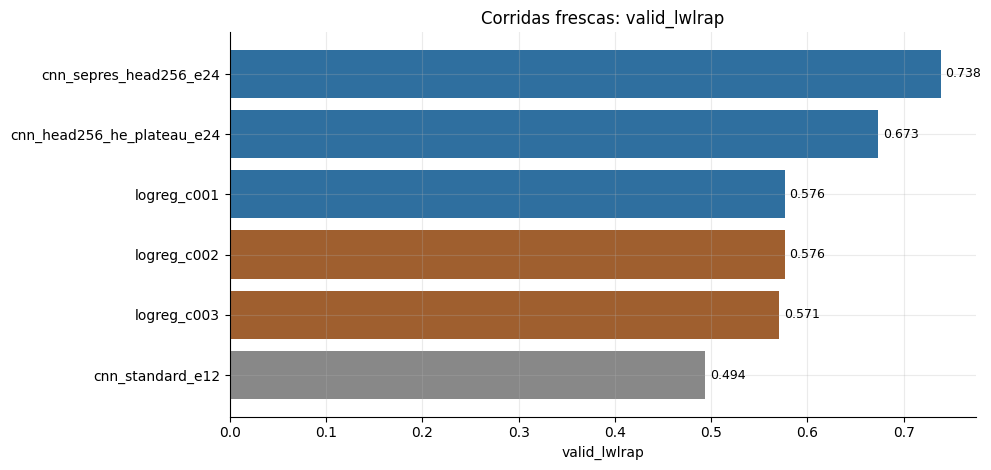

In [3]:
fresh = training_results[training_results['source'].eq('fresh_run')].copy()
fresh = fresh.sort_values('valid_lwlrap_num', ascending=False)
display(fresh[['run', 'model_family', 'config', 'valid_lwlrap', 'decision', 'notes']])
fresh.to_csv(RESULTS_DIR / 'fresh_runs_summary.csv', index=False)

fig, ax = plt.subplots(figsize=(10, 4.8))
colors = fresh['decision'].map({'keep': '#2f6f9f', 'discard': '#9f5f2f', 'reference': '#888888'}).fillna('#777777')
ax.barh(fresh['run'], fresh['valid_lwlrap_num'], color=colors)
ax.set_title('Corridas frescas: valid_lwlrap')
ax.set_xlabel('valid_lwlrap')
ax.invert_yaxis()
for y, value in enumerate(fresh['valid_lwlrap_num']):
    ax.text(value + 0.005, y, f'{value:.3f}', va='center', fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / '02_fresh_runs_valid_lwlrap.png', dpi=140, bbox_inches='tight')
plt.show()


## 3. Evidencia historica que no se reentrena

Algunos resultados importantes vienen de `investigation/`: corridas largas, full-train, blends y kernels de Kaggle. No conviene reentrenarlos cada vez en el notebook de entrega; se citan como evidencia historica y se conserva el artefacto asociado.


,run,source,model_family,config,valid_lwlrap,decision,notes
8,logmel_cnn_catsdogs_sepres_head256,historical_investigation,cnn_logmel,Separable residual + dense head256,0.807813,keep,Best individual holdout model among documented...
10,logmel_cnn_separable_temporal_bigru,historical_investigation,cnn_temporal,Separable residual backbone + BiGRU temporal head,0.797079,blend-only,Does not beat headsep individually but improve...
7,logmel_cnn_fashion_he_plateau_head256,historical_investigation,cnn_logmel,He + plateau + dense head256,0.783814,keep,Historical long run used to choose the full-tr...
9,logmel_cnn_temporal_bigru,historical_investigation,cnn_temporal,Light CNN + BiGRU temporal head,0.719812,discard,Learns but degrades the current blend
6,logmel_cnn_m128_f512,historical_investigation,cnn_logmel,Standard CNN log-mel image 128x512 longer run,0.523861,reference,Historical run; stronger than fresh e12 but we...
12,current85_sep_temporal_full15,fresh_candidate_blend,ensemble,0.85 * current translated final + 0.15 * separ...,NaN,candidate_needs_kaggle_notebook,Local holdout analog improves 0.841179 -> 0.84...
11,logmel_cnn_separable_temporal_bigru_full_e40_s...,fresh_run_full_train,cnn_temporal,"Full-train separable temporal BiGRU, 40 epochs...",NaN,candidate,Generated full-train branch for Kaggle-noteboo...


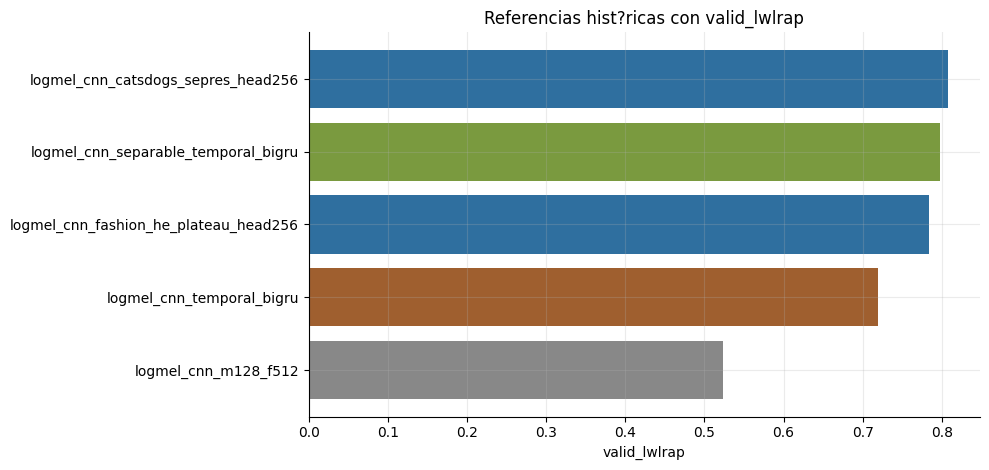

In [4]:
historical = training_results[training_results['source'].str.contains('historical|full_train|candidate', case=False, na=False)].copy()
historical = historical.sort_values(['valid_lwlrap_num', 'run'], ascending=[False, True])
display(historical[['run', 'source', 'model_family', 'config', 'valid_lwlrap', 'decision', 'notes']])
historical.to_csv(RESULTS_DIR / 'historical_runs_summary.csv', index=False)

plot_hist = historical.dropna(subset=['valid_lwlrap_num']).copy()
fig, ax = plt.subplots(figsize=(10, 4.8))
colors = plot_hist['decision'].map({'keep': '#2f6f9f', 'discard': '#9f5f2f', 'blend-only': '#7a9a3f', 'reference': '#888888'}).fillna('#777777')
ax.barh(plot_hist['run'], plot_hist['valid_lwlrap_num'], color=colors)
ax.set_title('Referencias historicas con valid_lwlrap')
ax.set_xlabel('valid_lwlrap')
ax.invert_yaxis()
fig.tight_layout()
fig.savefig(FIG_DIR / '03_historical_valid_lwlrap.png', dpi=140, bbox_inches='tight')
plt.show()


## 4. Decisiones: keep, blend-only, discard

La matriz de decisiones es el filtro entre investigacion y entrega. Una idea puede quedar como:

- `keep`: entra como componente defendible;
- `blend-only`: no gana sola, pero aporta diversidad;
- `discard`: se probo y no conviene promover;
- `reference`: sirve como baseline o smoke test.


,idea,baseline,evidence,course_support,decision,project_use,caveat
0,priors,#0,Private LB 0.03749; valida formato de submission,submission plumbing,reference,Smoke test de formato,No cuenta como modelo acustico
1,sklearn_logmel_stats,#0,Private LB 0.32714; primer salto grande usando...,log-mel features; multilabel; modelos lineales,keep,Baseline tabular defendible,Colapsa eje temporal
2,sklearn_logmel_c001,#1,Private LB 0.37607; regularizacion mejora cont...,regularizacion; desbalance; validacion,keep,Baseline tabular fuerte y rama de blend,No seguir micro-ajustando C si no mejora LB
3,extended_logmel_stats,#5,Valid local sube pero Private LB baja a 0.36167,feature engineering; validacion,discard,No promover al final,Ejemplo de sobreajuste local
4,cnn_logmel_image,#5,Valid 0.6528 y Private LB 0.52257,CNN; espectrogramas; BatchNorm; dropout,keep,Modelo neural base,Mas costoso y requiere cache log-mel image
5,cnn_sklearn_blend,#13,Private LB 0.56682; errores complementarios,ensembles; promediado de modelos,keep,Primer blend defendible,Pesos deben documentarse como empiricos si vie...
6,full_train_two_seed_cnn,#17,Private LB 0.58612; full curated + dos seeds r...,validacion; full-train final; bagging/ensembles,keep,Entrenamiento final de configuracion elegida,No agregar seeds indefinidamente
7,fashion_head256_training,#30,Private LB 0.64665 acumulado; valid local fuer...,inicializacion; learning-rate schedule; BatchN...,keep,Rama neural principal,Explicar como paquete de entrenamiento/cabeza ...
8,time_reverse_contrast_aug,#34,Valid baja contra head256,data augmentation; regularizacion,discard,No usar por defecto,Augmentations visuales pueden no preservar sem...
9,separable_residual_headsep,#44,Etapa sube a Private LB 0.65289; local 0.80781...,ResNet; Xception; separable conv; residual,keep,Rama final si artefactos estan validados,Incremento final marginal


,decision,count
0,keep,9
1,discard,4
2,blend-only,4
3,reference,1


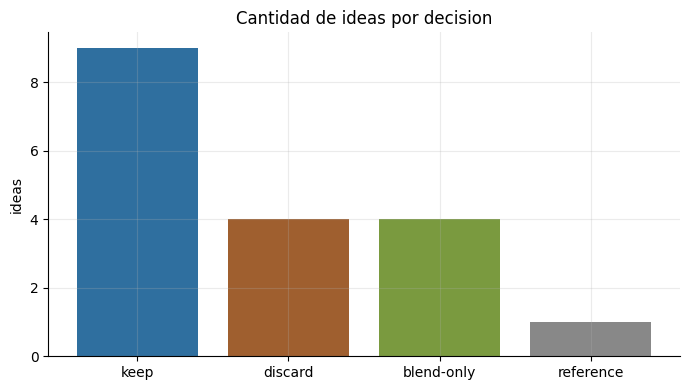

In [5]:
decision_view = decision_matrix[[
    'idea', 'baseline', 'evidence', 'course_support', 'decision', 'project_use', 'caveat'
]].copy()
display(decision_view)

decision_counts = decision_matrix['decision'].value_counts().rename_axis('decision').reset_index(name='count')
display(decision_counts)
decision_view.to_csv(RESULTS_DIR / 'decision_view.csv', index=False)
decision_counts.to_csv(RESULTS_DIR / 'decision_counts.csv', index=False)

fig, ax = plt.subplots(figsize=(7, 4))
color_map = {'keep': '#2f6f9f', 'blend-only': '#7a9a3f', 'discard': '#9f5f2f', 'reference': '#888888'}
ax.bar(decision_counts['decision'], decision_counts['count'], color=[color_map.get(x, '#777777') for x in decision_counts['decision']])
ax.set_title('Cantidad de ideas por decision')
ax.set_ylabel('ideas')
fig.tight_layout()
fig.savefig(FIG_DIR / '04_decision_counts.png', dpi=140, bbox_inches='tight')
plt.show()


## 5. Escalera de mejora

Esta seccion resume la historia competitiva completa. La diferencia con las secciones anteriores es que aca miramos el private LB acumulado: como fue subiendo el sistema desde priors hasta el blend final.


,stage,change,private_lb,why_it_matters,delta_vs_previous
0,#0,Priors de clase,0.03749,"valida formato, no escucha audio",NaN
1,#1,Sklearn log-mel stats,0.32714,primer modelo con informacion acustica,0.28965
2,#5,Regularizacion C=0.01,0.37607,baseline lineal menos sobreajustado,0.04893
3,#13,CNN log-mel 128x512,0.52257,preserva estructura tiempo-frecuencia,0.14650
4,#17,Blend CNN + sklearn,0.56682,errores complementarios,0.04425
5,#30,Full-train + dos seeds CNN,0.58612,mas datos y menos varianza,0.01930
6,#37,Fashion-style full-train,0.63080,"He, scheduler y cabeza mejoran entrenamiento",0.04468
7,#44,Fashion ensemble refinado,0.64665,ReLU/literal/seeds suman diversidad,0.01585
8,#51,Catsdogs separable/headsep blend,0.65289,arquitectura separable y transfer aportan poco...,0.00624
9,2026-06-28,Separable temporal BiGRU blend,0.65928,agrega lectura temporal explicita,0.00639


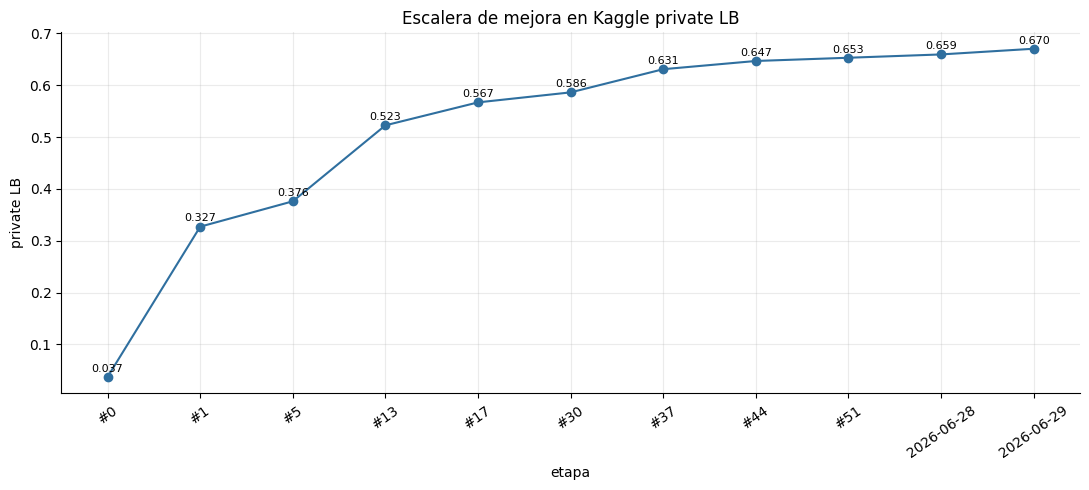

In [6]:
impact_ladder = pd.DataFrame([
    {'stage': '#0', 'change': 'Priors de clase', 'private_lb': 0.03749, 'why_it_matters': 'valida formato, no escucha audio'},
    {'stage': '#1', 'change': 'Sklearn log-mel stats', 'private_lb': 0.32714, 'why_it_matters': 'primer modelo con informacion acustica'},
    {'stage': '#5', 'change': 'Regularizacion C=0.01', 'private_lb': 0.37607, 'why_it_matters': 'baseline lineal menos sobreajustado'},
    {'stage': '#13', 'change': 'CNN log-mel 128x512', 'private_lb': 0.52257, 'why_it_matters': 'preserva estructura tiempo-frecuencia'},
    {'stage': '#17', 'change': 'Blend CNN + sklearn', 'private_lb': 0.56682, 'why_it_matters': 'errores complementarios'},
    {'stage': '#30', 'change': 'Full-train + dos seeds CNN', 'private_lb': 0.58612, 'why_it_matters': 'mas datos y menos varianza'},
    {'stage': '#37', 'change': 'Fashion-style full-train', 'private_lb': 0.63080, 'why_it_matters': 'He, scheduler y cabeza mejoran entrenamiento'},
    {'stage': '#44', 'change': 'Fashion ensemble refinado', 'private_lb': 0.64665, 'why_it_matters': 'ReLU/literal/seeds suman diversidad'},
    {'stage': '#51', 'change': 'Catsdogs separable/headsep blend', 'private_lb': 0.65289, 'why_it_matters': 'arquitectura separable y transfer aportan poco pero real'},
    {'stage': '2026-06-28', 'change': 'Separable temporal BiGRU blend', 'private_lb': 0.65928, 'why_it_matters': 'agrega lectura temporal explicita'},
    {'stage': '2026-06-29', 'change': 'Global-mel + SE + temporal 1024', 'private_lb': 0.67025, 'why_it_matters': 'normalizacion global y mayor contexto temporal'},
])
impact_ladder['delta_vs_previous'] = impact_ladder['private_lb'].diff()
display(impact_ladder)
impact_ladder.to_csv(RESULTS_DIR / 'impact_ladder.csv', index=False)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(impact_ladder['stage'], impact_ladder['private_lb'], marker='o', color='#2f6f9f')
ax.set_title('Escalera de mejora en Kaggle private LB')
ax.set_xlabel('etapa')
ax.set_ylabel('private LB')
ax.tick_params(axis='x', rotation=35)
for x, y in zip(impact_ladder['stage'], impact_ladder['private_lb']):
    ax.text(x, y + 0.01, f'{y:.3f}', ha='center', fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / '05_private_lb_ladder.png', dpi=140, bbox_inches='tight')
plt.show()


## 6. Que entra al final

El final no usa una sola idea. Usa componentes marcados como `keep` o `blend-only`, y la seleccion concreta queda cerrada en `04_final`. Aca dejamos el filtro de entrenamiento: que ideas tienen permiso metodologico para alimentar el final.


In [7]:
allowed = decision_matrix[decision_matrix['decision'].isin(['keep', 'blend-only'])].copy()
blocked = decision_matrix[decision_matrix['decision'].eq('discard')].copy()

display(allowed[['idea', 'decision', 'project_use', 'evidence', 'caveat']])
display(blocked[['idea', 'decision', 'evidence', 'caveat']])

selected_candidates = submission_candidates.sort_values('private_score', ascending=False, na_position='last')
display(selected_candidates[['candidate', 'private_score', 'decision', 'notes']].head(8))

allowed.to_csv(RESULTS_DIR / 'allowed_final_components.csv', index=False)
blocked.to_csv(RESULTS_DIR / 'discarded_components.csv', index=False)


,idea,decision,project_use,evidence,caveat
1,sklearn_logmel_stats,keep,Baseline tabular defendible,Private LB 0.32714; primer salto grande usando...,Colapsa eje temporal
2,sklearn_logmel_c001,keep,Baseline tabular fuerte y rama de blend,Private LB 0.37607; regularizacion mejora cont...,No seguir micro-ajustando C si no mejora LB
4,cnn_logmel_image,keep,Modelo neural base,Valid 0.6528 y Private LB 0.52257,Mas costoso y requiere cache log-mel image
5,cnn_sklearn_blend,keep,Primer blend defendible,Private LB 0.56682; errores complementarios,Pesos deben documentarse como empiricos si vie...
6,full_train_two_seed_cnn,keep,Entrenamiento final de configuracion elegida,Private LB 0.58612; full curated + dos seeds r...,No agregar seeds indefinidamente
7,fashion_head256_training,keep,Rama neural principal,Private LB 0.64665 acumulado; valid local fuer...,Explicar como paquete de entrenamiento/cabeza ...
9,separable_residual_headsep,keep,Rama final si artefactos estan validados,Etapa sube a Private LB 0.65289; local 0.80781...,Incremento final marginal
10,resnet50_imagenet_frozen,blend-only,Rama diversa de ensemble,Debil individual pero ayuda en blend por diver...,No presentarlo como mejor modelo individual
13,logmel_cnn_separable_temporal_bigru,blend-only,Candidato de mejora para blend,valid_lwlrap 0.797079; current+15% sube a 0.84...,No reemplazar la final Kaggle-verificada hasta...
14,geron_ensemble_search,blend-only,Candidato de post-procesado/ensemble,row_z+row_rank local 0.848191; CSV candidato g...,Mejora local chica y con riesgo de sobreajuste...


,idea,decision,evidence,caveat
3,extended_logmel_stats,discard,Valid local sube pero Private LB baja a 0.36167,Ejemplo de sobreajuste local
8,time_reverse_contrast_aug,discard,Valid baja contra head256,Augmentations visuales pueden no preservar sem...
11,noisy_direct_concat,discard,Valid curated cae a 0.3567,Requiere estrategia especifica de pretrain/fin...
12,logmel_cnn_temporal_bigru,discard,valid_lwlrap 0.719812; blend local baja a 0.84...,"Aprende y esta testeado, pero es debil individ..."


,candidate,private_score,decision,notes
11,current475_globalmel200_se125_f1024_200,0.67025,selected_final,Best verified Kaggle private score; copied to ...
10,current550_globalmel250_f1024_200,0.66996,validated_candidate,"Strong no-SE blend, close to selected final"
8,current645_globalmel_sep_temporal_full355,0.66561,validated_candidate,Global mel-band normalization candidate
9,current575_globalmel300_se125,0.66519,validated_candidate,SE helps locally but does not beat globalmel a...
0,translated_local,0.65289,superseded_verified,Matches investigation/kaggle_dataset_download_...
1,conservative_h10,0.65061,valid_backup,Matches investigation/kaggle_dataset_download_...
2,near_local,NaN,not_selected,No direct Kaggle score mapping found in submis...
3,replace_sep_h15,NaN,not_selected,No direct Kaggle score mapping found in submis...


## Comandos reproducibles principales

Baseline tabular:

```bash
python investigation/scripts/train_sklearn_variants.py --data-dir data --models logreg_c001 --feature-set basic --seed 42 --test-size 0.2
```

CNN base sobre log-mel:

```bash
python investigation/scripts/train_logmel_cnn.py --data-dir data --n-mels 128 --frames 512 --architecture standard --epochs 35 --seed 42 --test-size 0.2
```

CNN con mejoras de entrenamiento:

```bash
python investigation/scripts/train_logmel_cnn.py --data-dir data --n-mels 128 --frames 512 --initializer he_normal --scheduler plateau --head-hidden 256 --activation relu --epochs 54 --seed 42 --test-size 0.2
```

Rama temporal fuerte:

```bash
python investigation/scripts/train_logmel_cnn.py --data-dir data --architecture separable_temporal_bigru --n-mels 128 --frames 1024 --full-train
```

Los pesos de ensamble finales quedan documentados en `04_final/final_selection.md`.
